In [1]:
from typing import *
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

In [2]:
import seaborn as sns

In [3]:
import torchaudio
fpath="C:/Users/caovy/Desktop/Final code/Video_Anomaly_Detection/AI/notebooks/Abuse001_x264.mp4"
decoder = torchaudio.io.StreamReader(fpath)
stream_info = decoder.get_src_stream_info(0)
print(stream_info)

SourceVideoStream(media_type='video', codec='h264', codec_long_name='H.264 / AVC / MPEG-4 AVC / MPEG-4 part 10', format='yuv420p', bit_rate=1879833, num_frames=2729, bits_per_sample=8, metadata={'handler_name': 'VideoHandler', 'language': 'und'}, width=320, height=240, frame_rate=30.0)


In [4]:
import os
from typing import Dict, Any, Tuple, List
from dataclasses import dataclass

# class VideoDataLoader:
#     def __init__(self, fpath):
#         self.fpath = fpath

@dataclass
class VideoMetadata:
    fps: int
    num_frames: int
    resolution: Tuple[int, int]

    def __init__(self, fps, resolution, num_frames):
        self.fps = fps
        self.num_frames = num_frames
        self.resolution = resolution

    def to_dict(self) -> Dict[str, Any]:
        metadata = {
            "fps": self.fps,
            "num_frames": self.num_frames,
            "resolution": self.resolution
        }
        return metadata

    @staticmethod
    def get_video_metadata(fpath) -> Dict[str, Any]:
        import torchaudio

        decoder = torchaudio.io.StreamReader(fpath)
        stream_info = decoder.get_src_stream_info(0)

        return VideoMetadata(
            fps=getattr(stream_info, "frame_rate",None),
            resolution=(
                getattr(stream_info, "width",None),
                getattr(stream_info, "height",None)
            ),
            num_frames=getattr(stream_info, "num_frames",None)
        ).to_dict()




In [5]:
video = "C:/Users/caovy/Desktop/Final code/Video_Anomaly_Detection/AI/notebooks/Abuse001_x264.mp4"
print(VideoMetadata.get_video_metadata(video))


{'fps': 30.0, 'num_frames': 2729, 'resolution': (320, 240)}


In [6]:
from torch.utils.data import Dataset


In [7]:
class VideoDataset(Dataset):
    def __init__(self, video_files: List[Tuple[str, str]]):
        self.video_files = video_files

    def __getitem__(self, idx: int) -> Tuple[Dict[str, Any], str]:
        video_path, video_class = self.video_files[idx]
        metadata = VideoMetadata.get_video_metadata(video_path)
        return metadata, video_class
    def __len__(self):
        return len(self.video_files)

In [8]:
def get_video_files(root_dir: str) -> List[Tuple[str, str]]:
        """
        Duyệt qua tất cả thư mục con trong `root_dir`, lấy đường dẫn video và gán class.
        """
        video_files = []
        for subdir, _, files in os.walk(root_dir):
            for file in files:
                if file.endswith((".mp4", ".avi", ".mov", ".mkv")):  # Chỉ lấy file video
                    file_path = os.path.join(subdir, file)
                    class_name = os.path.basename(subdir)  # Lấy tên thư mục con làm class
                    video_files.append((file_path, class_name))
        return video_files


In [9]:
if __name__ == "__main__":
    # Lấy danh sách video từ cả 2 thư mục
    video_files = get_video_files("C:/Users/caovy/Desktop/testing")

    dataset = VideoDataset(video_files)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: zip(*x))

    for metadata_batch, class_batch in dataloader:
        for metadata, video_class in zip(metadata_batch, class_batch):
            print(f"Metadata: {metadata}")
            print(f"Class: {video_class}")


Metadata: {'fps': 30.0, 'num_frames': 2486, 'resolution': (320, 240)}
Class: Assault
Metadata: {'fps': 30.0, 'num_frames': 3223, 'resolution': (320, 240)}
Class: Assault
Metadata: {'fps': 30.0, 'num_frames': 467, 'resolution': (320, 240)}
Class: normal
Metadata: {'fps': 30.0, 'num_frames': 2729, 'resolution': (320, 240)}
Class: Abuse
Metadata: {'fps': 30.0, 'num_frames': 4187, 'resolution': (320, 240)}
Class: Arson
Metadata: {'fps': 30.0, 'num_frames': 1217, 'resolution': (320, 240)}
Class: Assault
Metadata: {'fps': 30.0, 'num_frames': 16794, 'resolution': (320, 240)}
Class: Abuse
Metadata: {'fps': 30.0, 'num_frames': 4198, 'resolution': (320, 240)}
Class: normal
Metadata: {'fps': 30.0, 'num_frames': 4439, 'resolution': (320, 240)}
Class: Arson
Metadata: {'fps': 30.0, 'num_frames': 480, 'resolution': (320, 240)}
Class: normal
Metadata: {'fps': 30.0, 'num_frames': 865, 'resolution': (320, 240)}
Class: Abuse
Metadata: {'fps': 30.0, 'num_frames': 3685, 'resolution': (320, 240)}
Class: Arr

In [10]:


def print_dataset_statistics(dataset: VideoDataset):
    total_videos = len(dataset)
    class_counts = defaultdict(int)
    fps_list = []
    num_frames_list = []
    resolutions = []
    durations = []

    for video_path, video_class in dataset.video_files:
        class_counts[video_class] += 1
        metadata = VideoMetadata.get_video_metadata(video_path)
        fps_list.append(metadata["fps"])
        num_frames_list.append(metadata["num_frames"])
        resolutions.append(metadata["resolution"])
        if metadata["fps"] and metadata["num_frames"]:
            durations.append(metadata["num_frames"] / metadata["fps"])

    avg_fps = np.mean(fps_list) if fps_list else 0
    avg_num_frames = np.mean(num_frames_list) if num_frames_list else 0
    avg_resolution = (
        int(np.mean([res[0] for res in resolutions])),
        int(np.mean([res[1] for res in resolutions]))
    ) if resolutions else (0, 0)
    min_duration = min(durations) if durations else 0
    max_duration = max(durations) if durations else 0
    avg_duration = np.mean(durations) if durations else 0

    print("=" * 50)
    print("DATASET STATISTICS")
    print(f"Tổng số video: {total_videos}")
    print("Số lượng video theo lớp:")
    for class_name, count in class_counts.items():
        print(f"  - {class_name}: {count} videos")
    print(f"FPS trung bình: {avg_fps:.2f}")
    print(f"Số frame trung bình: {avg_num_frames:.2f}")
    print(f"Độ phân giải trung bình: {avg_resolution}")
    print(f"Thời gian ngắn nhất: {min_duration:.2f} giây")
    print(f"Thời gian dài nhất: {max_duration:.2f} giây")
    print(f"Thời gian trung bình: {avg_duration:.2f} giây")
    print("=" * 50)

print_dataset_statistics(dataset)

DATASET STATISTICS
Tổng số video: 25
Số lượng video theo lớp:
  - Abuse: 5 videos
  - Arrest: 5 videos
  - Arson: 5 videos
  - Assault: 5 videos
  - normal: 5 videos
FPS trung bình: 30.00
Số frame trung bình: 3067.92
Độ phân giải trung bình: (320, 240)
Thời gian ngắn nhất: 15.57 giây
Thời gian dài nhất: 559.80 giây
Thời gian trung bình: 102.26 giây


C:\Users\caovy\AppData\Local\Temp\ipykernel_3100\3703627270.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0, 0], palette="viridis")


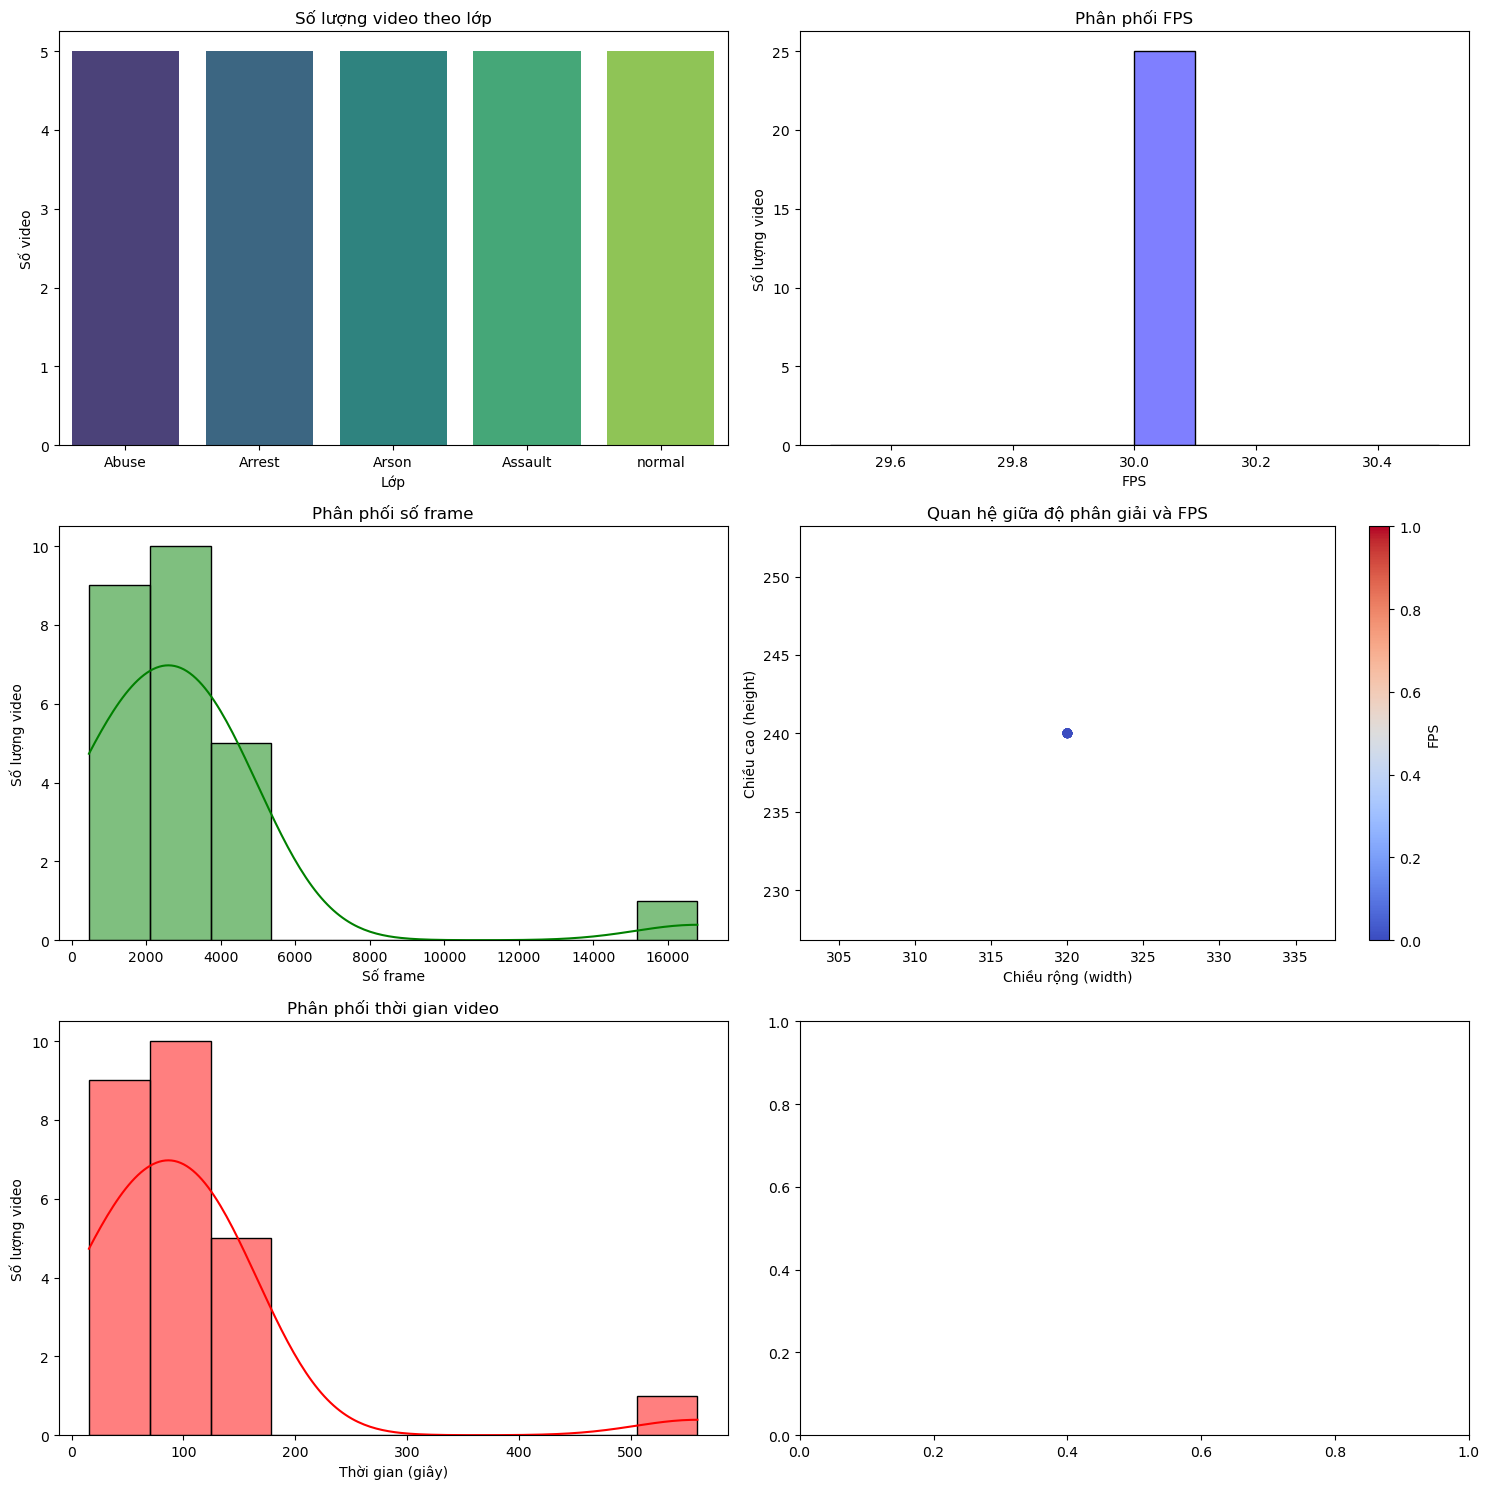

In [11]:


def plot_dataset_statistics(dataset: VideoDataset):
    """
    Vẽ các biểu đồ thống kê dataset:
    - Biểu đồ cột (số lượng video theo class)
    - Histogram FPS
    - Histogram số frame
    - Scatter plot độ phân giải & FPS
    - Histogram thời gian video
    - In ra thời gian ngắn nhất, dài nhất và trung bình của video
    """
    class_counts = defaultdict(int)
    fps_list = []
    num_frames_list = []
    durations = []  # Danh sách thời gian video
    resolutions = []

    for video_path, video_class in dataset.video_files:
        class_counts[video_class] += 1
        metadata = VideoMetadata.get_video_metadata(video_path)
        fps_list.append(metadata["fps"])
        num_frames_list.append(metadata["num_frames"])
        resolutions.append(metadata["resolution"])

        # Tính thời gian video (số frame / fps)
        duration = metadata["num_frames"] / metadata["fps"] if metadata["fps"] > 0 else 0
        durations.append(duration)

    widths = [res[0] for res in resolutions]
    heights = [res[1] for res in resolutions]

    # Tính thời gian ngắn nhất, dài nhất và trung bình
    min_duration = np.min(durations)
    max_duration = np.max(durations)
    avg_duration = np.mean(durations)

    # Tạo figure
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))

    # 1. Biểu đồ cột - Số lượng video theo class
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0, 0], palette="viridis")
    axes[0, 0].set_title("Số lượng video theo lớp")
    axes[0, 0].set_xlabel("Lớp")
    axes[0, 0].set_ylabel("Số video")

    # 2. Histogram - Phân phối FPS
    sns.histplot(fps_list, bins=10, kde=True, ax=axes[0, 1], color="blue")
    axes[0, 1].set_title("Phân phối FPS")
    axes[0, 1].set_xlabel("FPS")
    axes[0, 1].set_ylabel("Số lượng video")

    # 3. Histogram - Phân phối số frame
    sns.histplot(num_frames_list, bins=10, kde=True, ax=axes[1, 0], color="green")
    axes[1, 0].set_title("Phân phối số frame")
    axes[1, 0].set_xlabel("Số frame")
    axes[1, 0].set_ylabel("Số lượng video")

    # 4. Scatter plot - Độ phân giải & FPS
    axes[1, 1].scatter(widths, heights, c=fps_list, cmap="coolwarm", alpha=0.7)
    axes[1, 1].set_title("Quan hệ giữa độ phân giải và FPS")
    axes[1, 1].set_xlabel("Chiều rộng (width)")
    axes[1, 1].set_ylabel("Chiều cao (height)")
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap="coolwarm"), ax=axes[1, 1])
    cbar.set_label("FPS")

    # 5. Histogram - Phân phối thời gian video
    sns.histplot(durations, bins=10, kde=True, ax=axes[2, 0], color="red")
    axes[2, 0].set_title("Phân phối thời gian video")
    axes[2, 0].set_xlabel("Thời gian (giây)")
    axes[2, 0].set_ylabel("Số lượng video")

    # Hiển thị tất cả biểu đồ
    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ biểu đồ
plot_dataset_statistics(dataset)
